# PHOTON COUNT STATISTICS
For a given amount of time, how many photons will be detected? While coherent sources predictably result in Poissonian statistics, this measurement utilizes count histograms to characterize the statistical distributions of various light sources.

## Measurement
```tt.Counter``` counts number of events in ```BIN_WIDTH_PS``` ($\approx 1\mu s$) intervals. 

Connecting to Time Tagger...
Counting photons across 100,000 windows...
Hardware released. Plotting statistics...


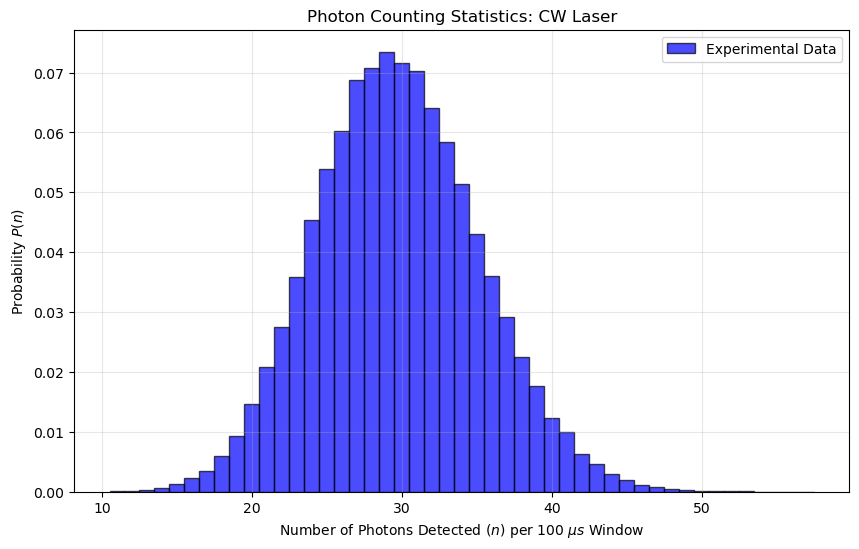

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os

# Define Parameters
SPAD_CH = 1                   # The channel with attenuated CW laser
BIN_WIDTH_PS = int(1e8)       # 100 microseconds (100,000,000 ps) per window
N_WINDOWS = 100000            # Collect 100,000 separate windows

print("Connecting to Time Tagger...")
tagger = tt.createTimeTagger()

# Initialize the Counter
# It will measure N_WINDOWS consecutive chunks of time, each BIN_WIDTH_PS long
counter = tt.Counter(tagger, channels=[SPAD_CH], binwidth=BIN_WIDTH_PS, n_values=N_WINDOWS)

# 2. Run the hardware measurement (Takes exactly 10 seconds total)
print(f"Counting photons across {N_WINDOWS:,} windows...")
counter.startFor(BIN_WIDTH_PS * N_WINDOWS, clear=True)
counter.waitUntilFinished()

# 3. Fetch the 1D array of counts (one integer per time window)
# getData() returns a 2D array [channels][values], so we grab index [0]
counts_per_window = counter.getData()[0]

# 4. Release hardware immediately
tt.freeTimeTagger(tagger)
print("Hardware released. Plotting statistics...")

# --- DATA ANALYSIS & PLOTTING ---
# Calculate the average number of photons per window (lambda in Poisson math)
mean_photons = np.mean(counts_per_window)

# Find the min and max counts to set up our X-axis bins
min_c = np.min(counts_per_window)
max_c = np.max(counts_per_window)
bins = np.arange(min_c, max_c + 2) - 0.5 # Center the bins on integers

plt.figure(figsize=(10, 6))

# Plot the experimental data as a histogram
# density=True normalizes it so the Y-axis is pure Probability
counts, edges, patches = plt.hist(counts_per_window, bins=bins, density=True, 
                                  alpha=0.7, color='blue', edgecolor='black', label='Experimental Data')

plt.title('Photon Counting Statistics: CW Laser')
plt.xlabel('Number of Photons Detected ($n$) per $100\ \mu s$ Window')
plt.ylabel('Probability $P(n)$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Save Data

In [ ]:
# Select name of dataset. Format: laserwavelen_power_note
RUN_NAME = "laser660nm_01_0_BS1" ##dark_01, laser_p1 , laser660nm
data_folder = "../data/raw/photoncount_statistics"
os.makedirs(data_folder, exist_ok=True)

# Format: photon_counts_spad[X]_[RUN_NAME].npy
filename = f"{data_folder}/photon_counts_spad{SPAD_CH}_{RUN_NAME}.npy"
np.save(filename, counts_per_window)
print(f"Data safely saved to: {filename}")

# DATA ANALYSIS
* Load Data. 
* Calculate Statistics and Visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import os

Size of photon_counts: 100000 
 Array query: [460 433 447 413 449 476 453 460 425 467] 
 Min:357, Max:546


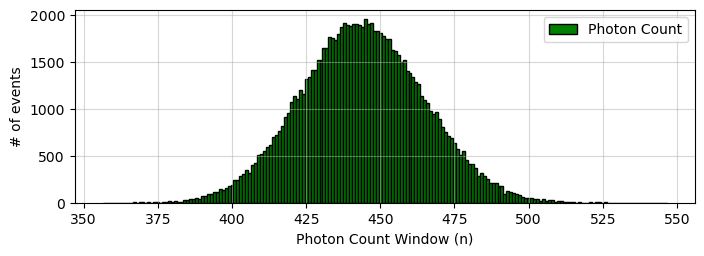

In [5]:

photon_counts = np.load("../data/raw/photoncount_statistics/photon_counts_spad1_laser660nm_01_0.npy")

#Array quick facts
print(f'Size of photon_counts: {photon_counts.size} \n Array query: {photon_counts[0:100:10]} \n Min:{np.min(photon_counts)}, Max:{np.max(photon_counts)}')

# Plot histogram 
bins = np.arange(np.min(photon_counts), np.max(photon_counts)+2) -0.5 # Center bins on integers
plt.figure(figsize=(8,2.5))
counts, edges, patches = plt.hist(photon_counts, bins = bins, density = False, color = 'green', edgecolor = 'black', label = 'Photon Count')
plt.xlabel('Photon Count Window (n)')
plt.ylabel('# of events')
plt.legend()
plt.grid(alpha = 0.5)
plt.show()



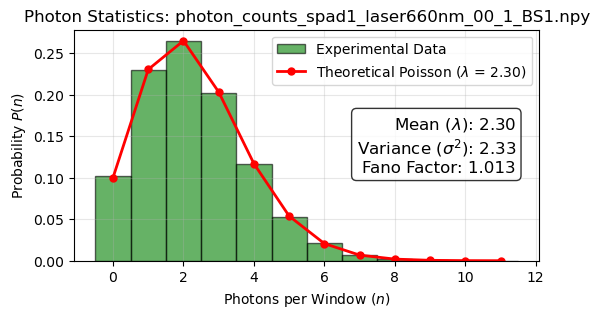

Processed: photon_counts_spad1_laser660nm_00_1_BS1.npy | Lambda: 2.30 | Fano: 1.013
--------------------------------------------------


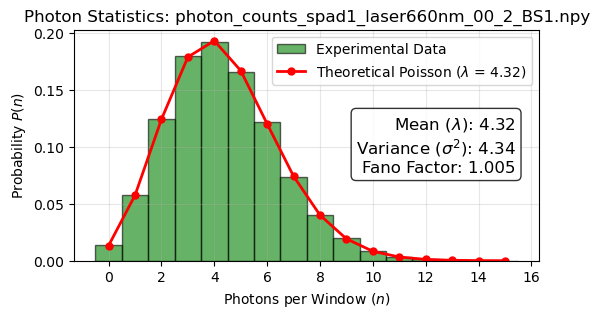

Processed: photon_counts_spad1_laser660nm_00_2_BS1.npy | Lambda: 4.32 | Fano: 1.005
--------------------------------------------------


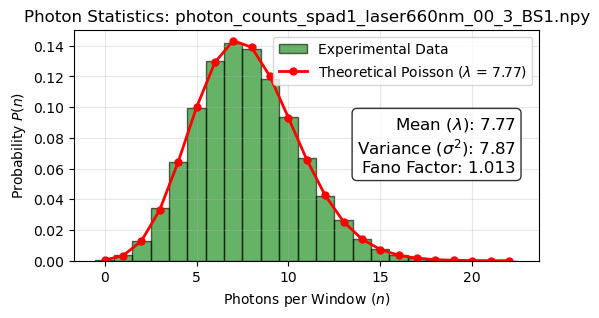

Processed: photon_counts_spad1_laser660nm_00_3_BS1.npy | Lambda: 7.77 | Fano: 1.013
--------------------------------------------------


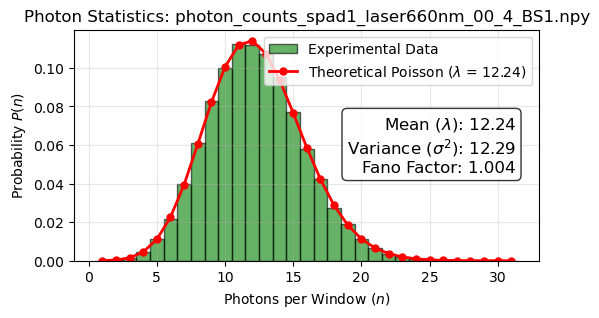

Processed: photon_counts_spad1_laser660nm_00_4_BS1.npy | Lambda: 12.24 | Fano: 1.004
--------------------------------------------------


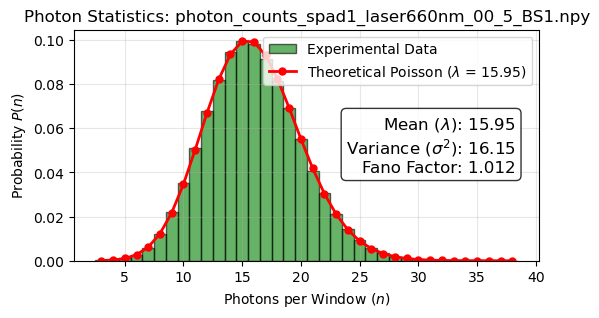

Processed: photon_counts_spad1_laser660nm_00_5_BS1.npy | Lambda: 15.95 | Fano: 1.012
--------------------------------------------------


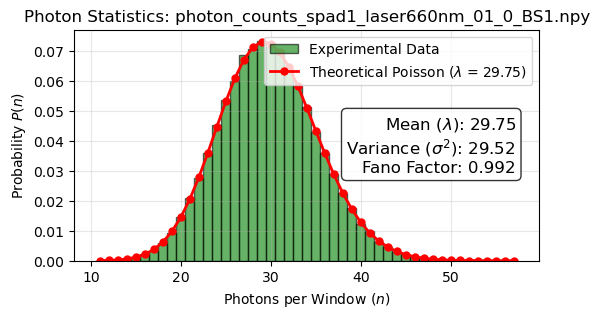

Processed: photon_counts_spad1_laser660nm_01_0_BS1.npy | Lambda: 29.75 | Fano: 0.992
--------------------------------------------------


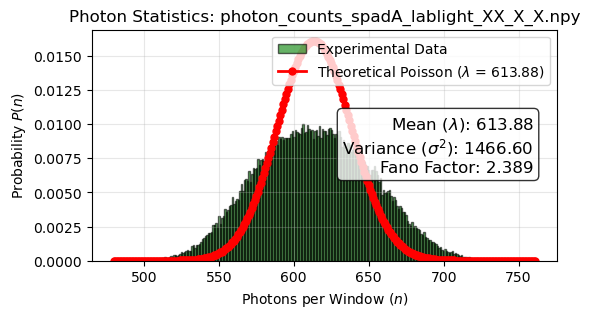

Processed: photon_counts_spadA_lablight_XX_X_X.npy | Lambda: 613.88 | Fano: 2.389
--------------------------------------------------


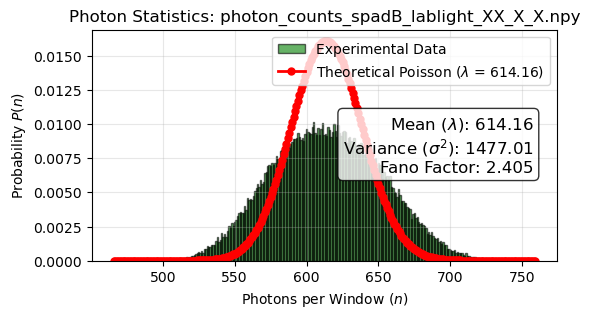

Processed: photon_counts_spadB_lablight_XX_X_X.npy | Lambda: 614.16 | Fano: 2.405
--------------------------------------------------


In [3]:
# Data directory
data_folder = "../data/raw/photoncount_statistics/"

# List of Datasets to import
run_files = [
    "photon_counts_spad1_laser660nm_00_1.npy",
    "photon_counts_spad1_laser660nm_00_5.npy",
    "photon_counts_spad1_laser660nm_01_0.npy"
]

run_files_BS = [
    "photon_counts_spad1_laser660nm_00_1_BS1.npy",
    "photon_counts_spad1_laser660nm_00_2_BS1.npy",
    "photon_counts_spad1_laser660nm_00_3_BS1.npy",
    "photon_counts_spad1_laser660nm_00_4_BS1.npy",
    "photon_counts_spad1_laser660nm_00_5_BS1.npy",
    "photon_counts_spad1_laser660nm_01_0_BS1.npy"
]

run_files_lablight = [
    "photon_counts_spadA_lablight_XX_X_X.npy",
    "photon_counts_spadB_lablight_XX_X_X.npy"
]

run_files_all = np.concatenate((run_files_BS, run_files_lablight))

# Iterate through each file
for filename in run_files_all:
    filepath = os.path.join(data_folder, filename)
    
    # Check if file exists
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}. Skipping...")
        continue
        
    # Load the data
    photon_counts = np.load(filepath)
    
    # Calculate lambda (mean) and variance
    lambda_param = np.mean(photon_counts)
    variance = np.var(photon_counts)
    
    # Calculate Fano factor (Variance / Mean)
    fano_factor = variance / lambda_param
    
    # --- PLOTTING ---
    plt.figure(figsize=(6, 3))
    
    # Setup histogram bins centered on integers
    min_c = np.min(photon_counts)
    max_c = np.max(photon_counts)
    bins = np.arange(min_c, max_c + 2) - 0.5 
    
    # Plot Experimental Histogram (MUST be density=True to match probability curve)
    plt.hist(photon_counts, bins=bins, density=True, color='green', 
             edgecolor='black', alpha=0.6, label='Experimental Data')
    
    # Setup Theoretical Poisson Curve
    x_theory = np.arange(min_c, max_c + 1)
    y_theory = poisson.pmf(x_theory, lambda_param)
    
    # Plot Theoretical Curve
    plt.plot(x_theory, y_theory, 'r-', marker='o', linewidth=2, 
             markersize=5, label=f'Theoretical Poisson ($\lambda$ = {lambda_param:.2f})')
    
    # Formatting
    plt.title(f'Photon Statistics: {filename}')
    plt.xlabel('Photons per Window ($n$)')
    plt.ylabel('Probability $P(n)$')
    
    # Add a text box with the critical statistics
    stats_text = f"Mean ($\lambda$): {lambda_param:.2f}\nVariance ($\sigma^2$): {variance:.2f}\nFano Factor: {fano_factor:.3f}"
    plt.gca().text(0.95, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=12,
                   verticalalignment='center', horizontalalignment='right', 
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    # Show plot (this pauses the loop until you close the figure, 
    # or displays them sequentially in a Jupyter Notebook)
    plt.show()
    
    print(f"Processed: {filename} | Lambda: {lambda_param:.2f} | Fano: {fano_factor:.3f}")
    print("-" * 50)

## Theory
Classical Electromagnetism models light with

$$
E(t) = E_0 e^{-i(\omega t + \phi(t))}.
$$

Phase coherence is captured by th $\phi(t)$ term. Phase coherence enables the classification of light into three quantum states: 

**Coherent Light:**

Coherent sources - like LASERs - are fields that oscilate with a precise phase. However, at the quantum level photons behave independently. The arrival of one photon gives no predictive information about the arrival of the next. In statistics, independent events follow Poission distribution where $\sigma^2 = \mu$. 

If the phase of the field is constant in time, we use the second quantization dualism with the harmonic oscilator which results in a coherent state. This state obays  $ a\hat |\alpha \rangle  = \alpha |\alpha \rangle $, where the eigenvalue is a complex number whose amplitude encodes the average photons ($ |\alpha|^2 = \mu$) and the angle is the macroscopic phase of the laser field. To find the probability of detecting *n* photons, we project $|\alpha \rangle$ into the Fock basis and recover the Poissonian distribution from $P(n) = |\langle n |\alpha \rangle |^2$. 

$$
|\alpha\rangle = e^{-\frac{|\alpha|^2}{2}} \sum_{n=0}^{\infty} \frac{\alpha^n}{\sqrt{n!}} |n\rangle
$$

**Thermal Sources:**

Non coherent sources, like stars, flames, light bulbs, or lasers passed through diffusers are also called *super-poissonian*. The bosonian nature of photons in these sources manifests in a phenomenon called bunching. Photons occupy same energetic states and we observe clumps of photons followed by dark lulls. This broadens the distrubution into a Bose Einstein distribution. $\sigma^2 = \mu + \mu^2$

In this regime, $E(t) = \sum_i E_i e^{-i(\omega t + \phi_i(t))}$.When the electric field is a Gausian random variable, $P(I) = \frac{I}{\langle I\rangle } e^{-\frac{I}{\langle I\rangle }}$ which leads to $ g^{(2)} = \frac{\langle I^2\rangle}{\langle I\rangle ^2 } = 2$

**Quantum Light:** 

Single photon sources. Photons arrive one by one leading to an effect called *anti-bunching*. The resulting statistical distribution is tighter that Poissonian i.e $\sigma^2 < \mu$